# Music Recommendation System

This notebook implements a Music Recommendation System using the Spotify Tracks Dataset (`dataset.csv`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Set styling
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('dataset.csv')
print(f"Loaded {df.shape[0]} tracks with {df.shape[1]} features.")
df.head()

Loaded 114000 tracks with 21 features.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.shape

(114000, 21)

In [ ]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
df[df["artists"].isnull()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
df.drop(65900, inplace=True)

In [ ]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated(subset=["track_name", "artists"])]

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18,jason mraz;colbie caillat,we sing. we dance. we steal things.,lucky,68,189613,False,0.625,0.414,0,-8.700,1,0.0369,0.29400,0.000000,0.1510,0.6690,130.088,4,acoustic
20,jason mraz,we sing. we dance. we steal things.,i'm yours,75,242946,False,0.703,0.444,11,-9.331,1,0.0417,0.55900,0.000000,0.0973,0.7120,150.960,4,acoustic
22,a great big world;christina aguilera,is there anybody out there? - track by track c...,say something,70,229400,False,0.407,0.147,2,-8.822,1,0.0355,0.85700,0.000003,0.0913,0.0765,141.284,3,acoustic
28,jason mraz,christmas time,winter wonderland,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.78800,0.000000,0.1460,0.6640,145.363,4,acoustic
29,jason mraz,perfect christmas hits,winter wonderland,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.78800,0.000000,0.1460,0.6640,145.363,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113882,bryan & katie torwalt,i've got good news (live) [deluxe],good news - live,23,266632,False,0.473,0.474,6,-9.175,1,0.0558,0.39500,0.000000,0.1630,0.2510,140.746,4,world-music
113917,hillsong worship;mi-kaisha rose,never walk alone (live),never walk alone - live,41,348619,False,0.420,0.553,5,-8.049,1,0.0332,0.14100,0.000000,0.1030,0.2140,143.804,4,world-music
113946,cesária evora,best of,petit pays,22,226160,False,0.555,0.486,4,-11.584,0,0.0324,0.79000,0.000000,0.2560,0.8360,156.170,4,world-music
113951,passion;kristian stanfill,more like jesus (live),more like jesus - live,44,338694,False,0.404,0.676,10,-5.468,1,0.0354,0.02740,0.000000,0.3520,0.1630,144.056,3,world-music


In [ ]:
df.dtypes

artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [ ]:
df = df.drop(columns=["Unnamed: 0", "track_id"])

KeyError: "['Unnamed: 0', 'track_id'] not found in axis"

In [ ]:
if "df" not in globals() or df is None:
    df = pd.read_csv("dataset.csv")
    df = df.drop(columns=["Unnamed: 0", "track_id"], errors="ignore")
df["popularity"].describe()


count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [ ]:
if "df" not in globals() or df is None:
    df = pd.read_csv("dataset.csv")
    df = df.drop(columns=["Unnamed: 0", "track_id"], errors="ignore")
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


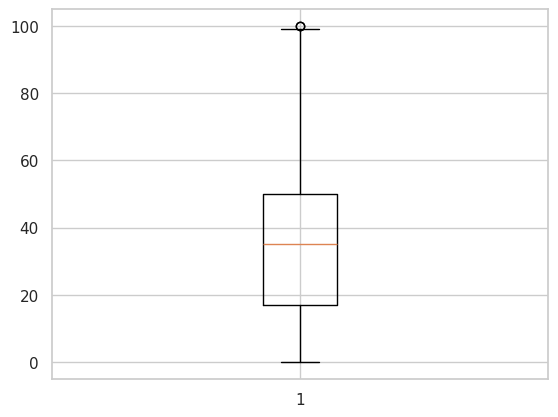

In [ ]:
plt.boxplot(df["popularity"])
plt.show()

In [ ]:
text_columns = ["artists", "album_name", "track_name", "track_genre"]

for col in text_columns:
    df[col] = (df[col].str.lower().str.strip())

In [ ]:
df["track_genre"].unique

df["artists"].unique

<bound method Series.unique of 0                    gen hoshino
1                   ben woodward
2         ingrid michaelson;zayn
3                   kina grannis
4               chord overstreet
                   ...          
113995             rainy lullaby
113996             rainy lullaby
113997             cesária evora
113998          michael w. smith
113999             cesária evora
Name: artists, Length: 113999, dtype: object>

In [ ]:
[df["duration_ms"] <= 0]

[0         False
 1         False
 2         False
 3         False
 4         False
           ...  
 113995    False
 113996    False
 113997    False
 113998    False
 113999    False
 Name: duration_ms, Length: 113999, dtype: bool]

## Doing EDA


In [ ]:
df[["track_name", "tempo"]].head()

,track_name,tempo
0,comedy,87.917
1,ghost - acoustic,77.489
2,to begin again,76.332
3,can't help falling in love,181.740
4,hold on,119.949


In [ ]:
# Top song Artist and Songs
df["artists"].value_counts().head(10)

artists
the beatles        279
george jones       271
stevie wonder      236
linkin park        224
ella fitzgerald    222
prateek kuhad      217
feid               202
chuck berry        190
håkan hellström    183
onerepublic        181
Name: count, dtype: int64

In [ ]:
df["track_name"].value_counts().head(10)

track_name
run rudolph run                   151
halloween                          88
frosty the snowman                 84
little saint nick - 1991 remix     76
last last                          75
christmas time                     72
cómo se siente - remix             64
sleigh ride                        61
rumbatón                           60
x última vez                       58
Name: count, dtype: int64

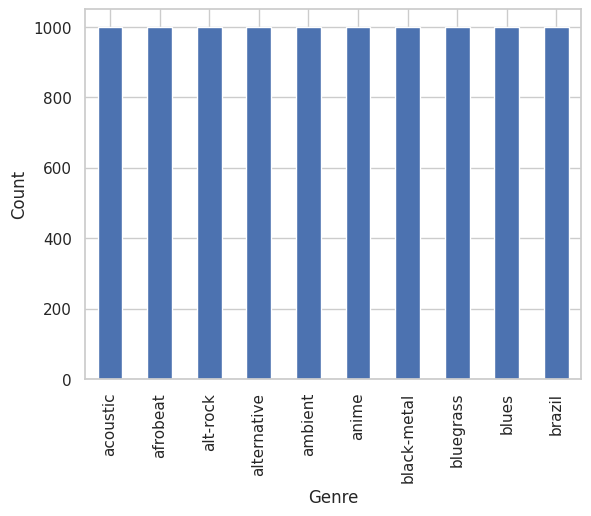

In [ ]:
df["track_genre"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

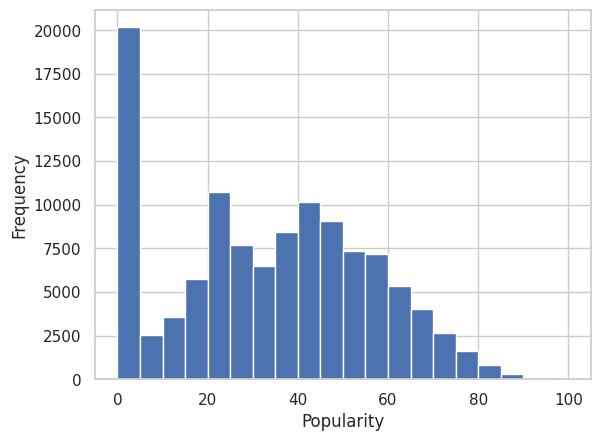

In [ ]:
# popularity distribution

plt.hist(df["popularity"], bins=20)

plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.show()

In [ ]:
(df["popularity"] == 0).sum()